# Attrition Modeling

## Load data

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/processed/HRDataset_v14_engineered.csv")

In [3]:
df.head()

,employee_name,employee_id,married_id,marital_status_id,gender_id,emp_status_id,dept_id,perf_score_id,from_diversity_job_fair_id,salary,...,age,years_since_review,age_at_hire,tenure_days,tenure_years,months_since_review,generation,absent_rate,lateness_flag,high_engagement_flag
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,36.476386,0.952772,27.986311,3101,8.490075,11.433265,Millennials,0.117785,True,False
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,44.657084,3.849418,39.901437,444,1.215606,46.193018,Generation X,13.984797,True,False
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,31.279945,7.627652,22.789870,447,1.223819,91.531828,Millennials,2.451342,True,False
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,31.258042,0.991102,19.277207,4376,11.980835,11.893224,Millennials,1.252000,True,False
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,30.310746,3.912389,21.837098,1884,5.158111,46.948665,Millennials,0.387739,True,False


## Prepare features for modeling

In [4]:
# list non-numeric columns
non_numeric_cols = df.select_dtypes(exclude=["number"]).columns
print(non_numeric_cols)

Index(['employee_name', 'position', 'state', 'dob', 'sex', 'marital_desc',
       'citizen_desc', 'hispanic_latino', 'race_desc', 'date_of_hire',
       'date_of_termination', 'term_reason', 'employment_status', 'department',
       'manager_name', 'recruitment_source', 'performance_score',
       'last_performance_review_date', 'salary_band', 'engagement_quartile',
       'generation', 'lateness_flag', 'high_engagement_flag'],
      dtype='object')


In [5]:
df.employment_status.value_counts()

employment_status
Active                    207
Voluntarily Terminated     88
Terminated for Cause       16
Name: count, dtype: int64

In [6]:
# list numeric columns
numeric_cols = df.select_dtypes(include=["number"]).columns
print(numeric_cols)

Index(['employee_id', 'married_id', 'marital_status_id', 'gender_id',
       'emp_status_id', 'dept_id', 'perf_score_id',
       'from_diversity_job_fair_id', 'salary', 'termd', 'position_id', 'zip',
       'manager_id', 'engagement_survey', 'emp_satisfaction',
       'special_projects_count', 'days_late_last_30', 'absences',
       'quality_of_hire', 'tenure', 'salary_relative_to_dept', 'promoted',
       'age', 'years_since_review', 'age_at_hire', 'tenure_days',
       'tenure_years', 'months_since_review', 'absent_rate'],
      dtype='object')


In [7]:
# from non_numeric_cols, drop employee_name, date_of_termination, and term_reason
categorical_cols = non_numeric_cols.drop(
    ["employee_name", "date_of_termination", "term_reason"]
)
print(categorical_cols)

Index(['position', 'state', 'dob', 'sex', 'marital_desc', 'citizen_desc',
       'hispanic_latino', 'race_desc', 'date_of_hire', 'employment_status',
       'department', 'manager_name', 'recruitment_source', 'performance_score',
       'last_performance_review_date', 'salary_band', 'engagement_quartile',
       'generation', 'lateness_flag', 'high_engagement_flag'],
      dtype='object')


In [8]:
# from numeric cols, drop employee_id, emp_status_id, and termd
numeric_cols = numeric_cols.drop(["employee_id"])
print(numeric_cols)

Index(['married_id', 'marital_status_id', 'gender_id', 'emp_status_id',
       'dept_id', 'perf_score_id', 'from_diversity_job_fair_id', 'salary',
       'termd', 'position_id', 'zip', 'manager_id', 'engagement_survey',
       'emp_satisfaction', 'special_projects_count', 'days_late_last_30',
       'absences', 'quality_of_hire', 'tenure', 'salary_relative_to_dept',
       'promoted', 'age', 'years_since_review', 'age_at_hire', 'tenure_days',
       'tenure_years', 'months_since_review', 'absent_rate'],
      dtype='object')


In [9]:
# separate categorical columns into categorical and date columns
date_cols = categorical_cols[categorical_cols.str.contains("date")]
categorical_cols = categorical_cols.drop(date_cols)

print("Categorical columns:", categorical_cols)
print("Date columns:", date_cols)

Categorical columns: Index(['position', 'state', 'dob', 'sex', 'marital_desc', 'citizen_desc',
       'hispanic_latino', 'race_desc', 'employment_status', 'department',
       'manager_name', 'recruitment_source', 'performance_score',
       'salary_band', 'engagement_quartile', 'generation', 'lateness_flag',
       'high_engagement_flag'],
      dtype='object')
Date columns: Index(['date_of_hire', 'last_performance_review_date'], dtype='object')


In [10]:
# convert date columns to numeric (number of seconds since epoch) for modeling
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce").astype(int) / 10**9

print(df[date_cols].head())

   date_of_hire  last_performance_review_date
0  1.309824e+09                  1.547683e+09
1  1.427674e+09                  1.456272e+09
2  1.309824e+09                  1.337040e+09
3  1.199664e+09                  1.546474e+09
4  1.310342e+09                  1.454285e+09


In [11]:
# keep only numeric, categorical, and date columns for modeling
modeling_cols = numeric_cols.union(categorical_cols).union(date_cols)
df = df[modeling_cols]

In [12]:
X = df.drop(columns=["termd", "employment_status"])
y_termd = df["termd"]
y_employment_status = df["employment_status"]

In [13]:
# convert categorical columns to numeric using one-hot encoding
categorical_cols = categorical_cols.drop(["employment_status"])
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X.head()

,absences,absent_rate,age,age_at_hire,date_of_hire,days_late_last_30,dept_id,emp_satisfaction,emp_status_id,engagement_survey,...,salary_band_100k-150k,salary_band_150k-200k,salary_band_200k+,salary_band_50k-100k,engagement_quartile_Q2,engagement_quartile_Q3,engagement_quartile_Q4,generation_Generation X,generation_Millennials,high_engagement_flag_True
0,1,0.117785,36.476386,27.986311,1.309824e+09,0,5,5,1,4.60,...,False,False,False,True,False,True,False,False,True,False
1,17,13.984797,44.657084,39.901437,1.427674e+09,0,3,3,5,4.96,...,True,False,False,False,False,False,True,True,False,False
2,3,2.451342,31.279945,22.789870,1.309824e+09,0,5,3,5,3.02,...,False,False,False,True,False,False,False,False,True,False
3,15,1.252000,31.258042,19.277207,1.199664e+09,0,5,5,1,4.84,...,False,False,False,True,False,False,True,False,True,False
4,2,0.387739,30.310746,21.837098,1.310342e+09,0,5,4,5,5.00,...,False,False,False,True,False,False,True,False,True,False


In [14]:
y_employment_status.value_counts()

employment_status
Active                    207
Voluntarily Terminated     88
Terminated for Cause       16
Name: count, dtype: int64

In [15]:
# convert y_employment_status to numeric where:
# Voluntarily Terminated = 0
# Terminated for Cause = 1
# Active = 2

employment_status_map = {
    "Active": 2,
    "Terminated for Cause": 1,
    "Voluntarily Terminated": 0
}
reverse_employment_status_map = {v: k for k, v in employment_status_map.items()}
y_employment_status = y_employment_status.map(
    employment_status_map
)
y_employment_status.value_counts()

employment_status
2    207
0     88
1     16
Name: count, dtype: int64

In [50]:
df.to_csv("../data/processed/HRDataset_v14_model_ready.csv", index=False)

## Modeling attrition (predicting: termd)

In [16]:
# prepare data for modeling
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y_termd, test_size=0.2, random_state=42
)

### baseline logistic regression

In [17]:
# model logistic regression (normalize numeric features first)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
# evaluate model
from sklearn.metrics import classification_report, confusion_matrix


y_pred = logreg.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        41
           1       1.00      0.82      0.90        22

    accuracy                           0.94        63
   macro avg       0.96      0.91      0.93        63
weighted avg       0.94      0.94      0.93        63

[[41  0]
 [ 4 18]]


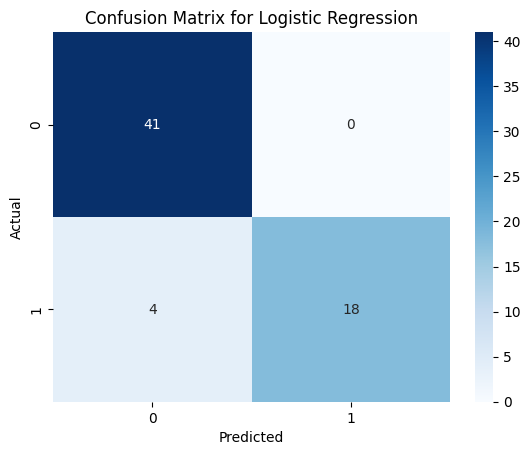

In [19]:
# pretty confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

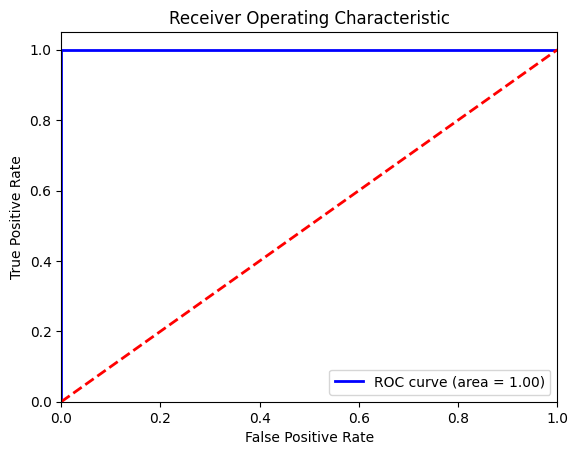

In [20]:
# ROC curve
from sklearn.metrics import roc_curve, auc


y_prob = logreg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", lw=2, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.show()

### xgboost

In [21]:
# model XGBoost classifier
from xgboost import XGBClassifier


xgb = XGBClassifier(eval_metric="logloss")
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [22]:
# evaluate XGBoost model
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        22

    accuracy                           1.00        63
   macro avg       1.00      1.00      1.00        63
weighted avg       1.00      1.00      1.00        63

[[41  0]
 [ 0 22]]


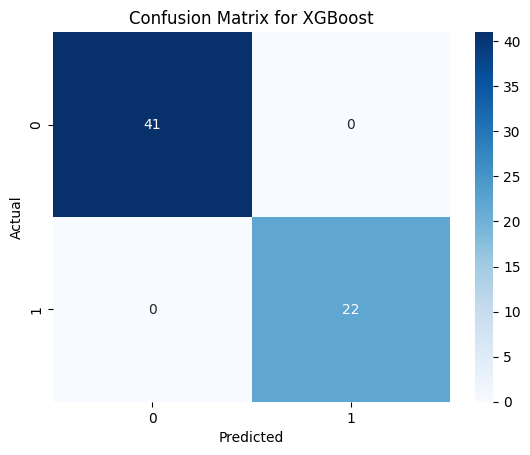

In [23]:
# pretty confusion matrix for XGBoost
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for XGBoost")
plt.show()

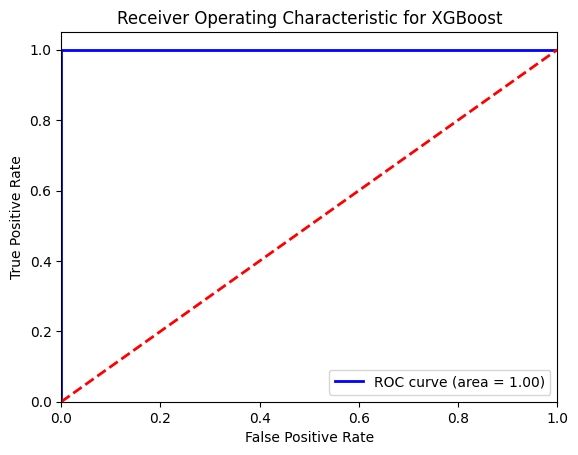

In [24]:
# ROC curve for XGBoost
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.figure()
plt.plot(fpr_xgb, tpr_xgb, color="blue", lw=2, label="ROC curve (area = %0.2f)" % roc_auc_xgb)
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic for XGBoost")
plt.legend(loc="lower right")
plt.show()

## Modeling attrition (predicting: employment_status)

In [25]:
# perform same split but with y_employment_status as the target variable instead of y_termd
X_train, X_test, y_train, y_test = train_test_split(
    X, y_employment_status, test_size=0.2, random_state=42
)

In [26]:
# for train and test sets, keep only the indexes where y_employment_status is not 2 (i.e. only keep rows where employment_status is Terminated for Cause or Voluntarily Terminated)
train_indexes = y_train[y_train != 2].index
test_indexes = y_test[y_test != 2].index
X_train = X_train.loc[train_indexes]
y_train = y_train.loc[train_indexes]
X_test = X_test.loc[test_indexes]
y_test = y_test.loc[test_indexes]

### baseline logistic regression

In [27]:
# model logistic regression (normalize numeric features first)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg_2 = LogisticRegression(max_iter=1000)
logreg_2.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
# evaluate model
y_pred = logreg_2.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92        18
           1       1.00      0.25      0.40         4

    accuracy                           0.86        22
   macro avg       0.93      0.62      0.66        22
weighted avg       0.88      0.86      0.83        22

[[18  0]
 [ 3  1]]


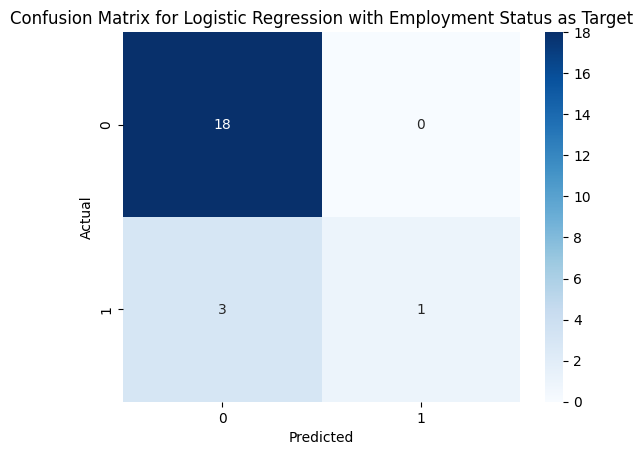

In [29]:
# pretty confusion matrix for logistic regression with y_employment_status as target
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Logistic Regression with Employment Status as Target")
plt.show()

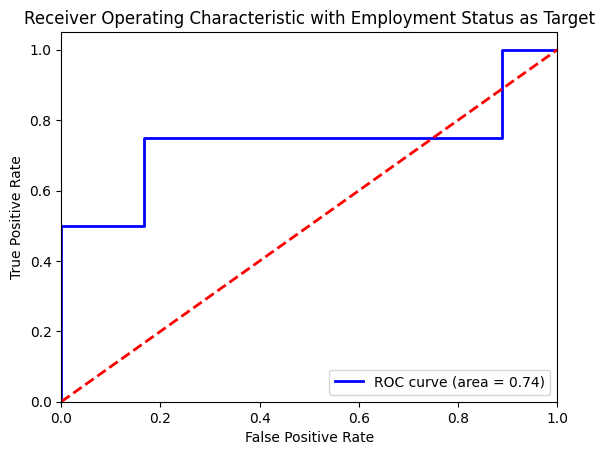

In [30]:
# ROC curve
y_prob = logreg_2.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", lw=2, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic with Employment Status as Target")
plt.legend(loc="lower right")
plt.show()

### xgboost

In [31]:
# model XGBoost classifier
xgb_2 = XGBClassifier(eval_metric="logloss")
xgb_2.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [32]:
# evaluate XGBoost model
y_pred_xgb = xgb_2.predict(X_test)
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00         4

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22

[[18  0]
 [ 0  4]]


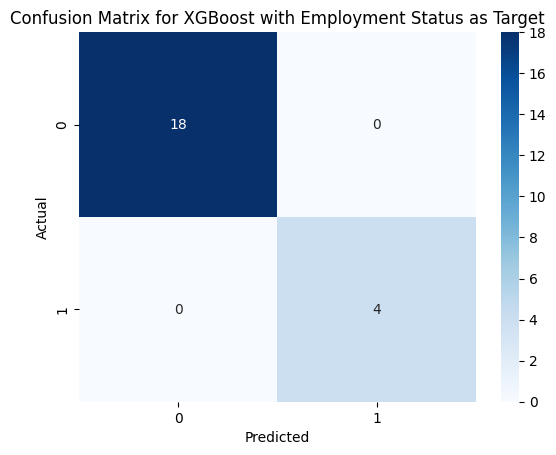

In [33]:
# pretty confusion matrix for XGBoost with y_employment_status as target
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for XGBoost with Employment Status as Target")
plt.show()

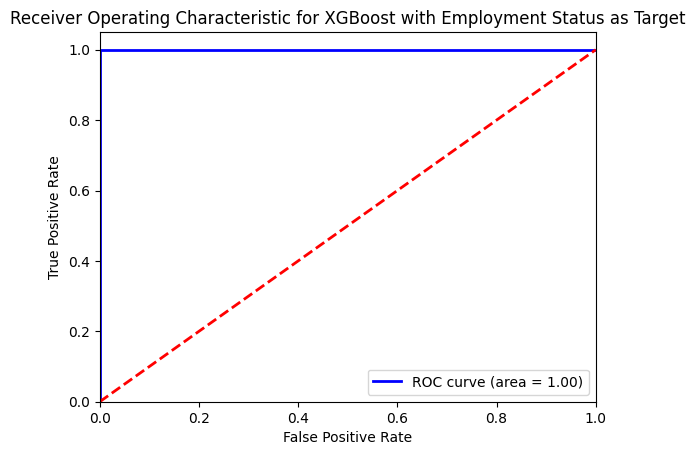

In [34]:
# ROC curve for XGBoost
y_prob_xgb = xgb_2.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.figure()
plt.plot(fpr_xgb, tpr_xgb, color="blue", lw=2, label="ROC curve (area = %0.2f)" % roc_auc_xgb)
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic for XGBoost with Employment Status as Target")
plt.legend(loc="lower right")
plt.show()

## Stacking (ensemble) XGBoost approaches

In [47]:
# function takes a data point (row), first uses xbg_1 to predict probability of termination, then uses xgb_2 to predict probability of being voluntarily terminated vs terminated for cause, and returns a final prediction of whether the employee will be voluntarily terminated, terminated for cause, or remain active
def predict_employment_status(row):
    # reshape row to be 2D array for prediction
    row_reshaped = row.values.reshape(1, -1)
    # predict probability of termination using xgb_1
    term_pred = xgb.predict(row_reshaped)[0]
    # if probability of termination is greater than 0.5, predict employment status using xgb_2
    if term_pred == 1:
        status_pred = xgb_2.predict(row_reshaped)[0]
        if status_pred == 0:
            return 0  # "Voluntarily Terminated"
        else:
            return 1  # "Terminated for Cause"
    else:
        return 2  # "Active"

In [48]:
# set up same train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_employment_status, test_size=0.2, random_state=42
)

In [49]:
# use function to predict employment status for each row in the test set
y_pred_employment_status = X_test.apply(predict_employment_status, axis=1)

# evaluate predictions
print(classification_report(y_test, y_pred_employment_status))
print(confusion_matrix(y_test, y_pred_employment_status))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00        41

    accuracy                           1.00        63
   macro avg       1.00      1.00      1.00        63
weighted avg       1.00      1.00      1.00        63

[[18  0  0]
 [ 0  4  0]
 [ 0  0 41]]
